# Stage 6i — Figure 6 out-of-distribution extension

Loads and plots the Stage 6i caches. **No compute in any cell**: the generation
calls are commented out below on purpose. `jupyter nbconvert --execute` enforces a
4200 s per-cell timeout, which destroyed a 70-minute run once already
(`REVISIONS.md`, 2026-08-13).

Provenance and citations for every scenario: `SCENARIOS.md`.
How the emulator evaluation is run, and the four ways to get it wrong: `OOD.md`.

In [1]:
import pickle
from pathlib import Path

import numpy as np

import utils_plotting

OOD_DIR = Path("data/SI_results/fig6_ood")

# --- Regeneration (do NOT run in this notebook) -----------------------------
# Phase A, local, ~2 min:
#     python scripts/6i_fig6_ood_extension.py build
# Phase B, CLUSTER ONLY - checkpoints/multi_retuned_smooth/ is not on this
# machine (12 GB; see MISSING_DATA.md):
#     python scripts/submit_fig6_ood_eval.py          # 50-task SLURM array
#     python scripts/6j_fig6_ood_evaluate.py --mode collect   # after pulling partials

scenarios = pickle.load(open(OOD_DIR / "fig6_ood_scenarios.pkl", "rb"))
sweep = pickle.load(open(OOD_DIR / "fig6_ood_seed_sweep.pkl", "rb"))
print(f"{len(scenarios['scenarios'])} scenarios, {len(sweep)} seeds")

11 scenarios, 50 seeds


## 1. The scenario roster

Six panels — one per forcing agent plus the SCM-simulated GMST — with one line per
scenario. In-sample CMIP7 references are the thin grey lines.

The CO2-only scenarios are piControl-branched: RCMIP labels their branch year 1850,
so `esm-bell-*` "peaks at 1899". They share the calendar axis for compactness but
are not contemporaneous with the historical period.

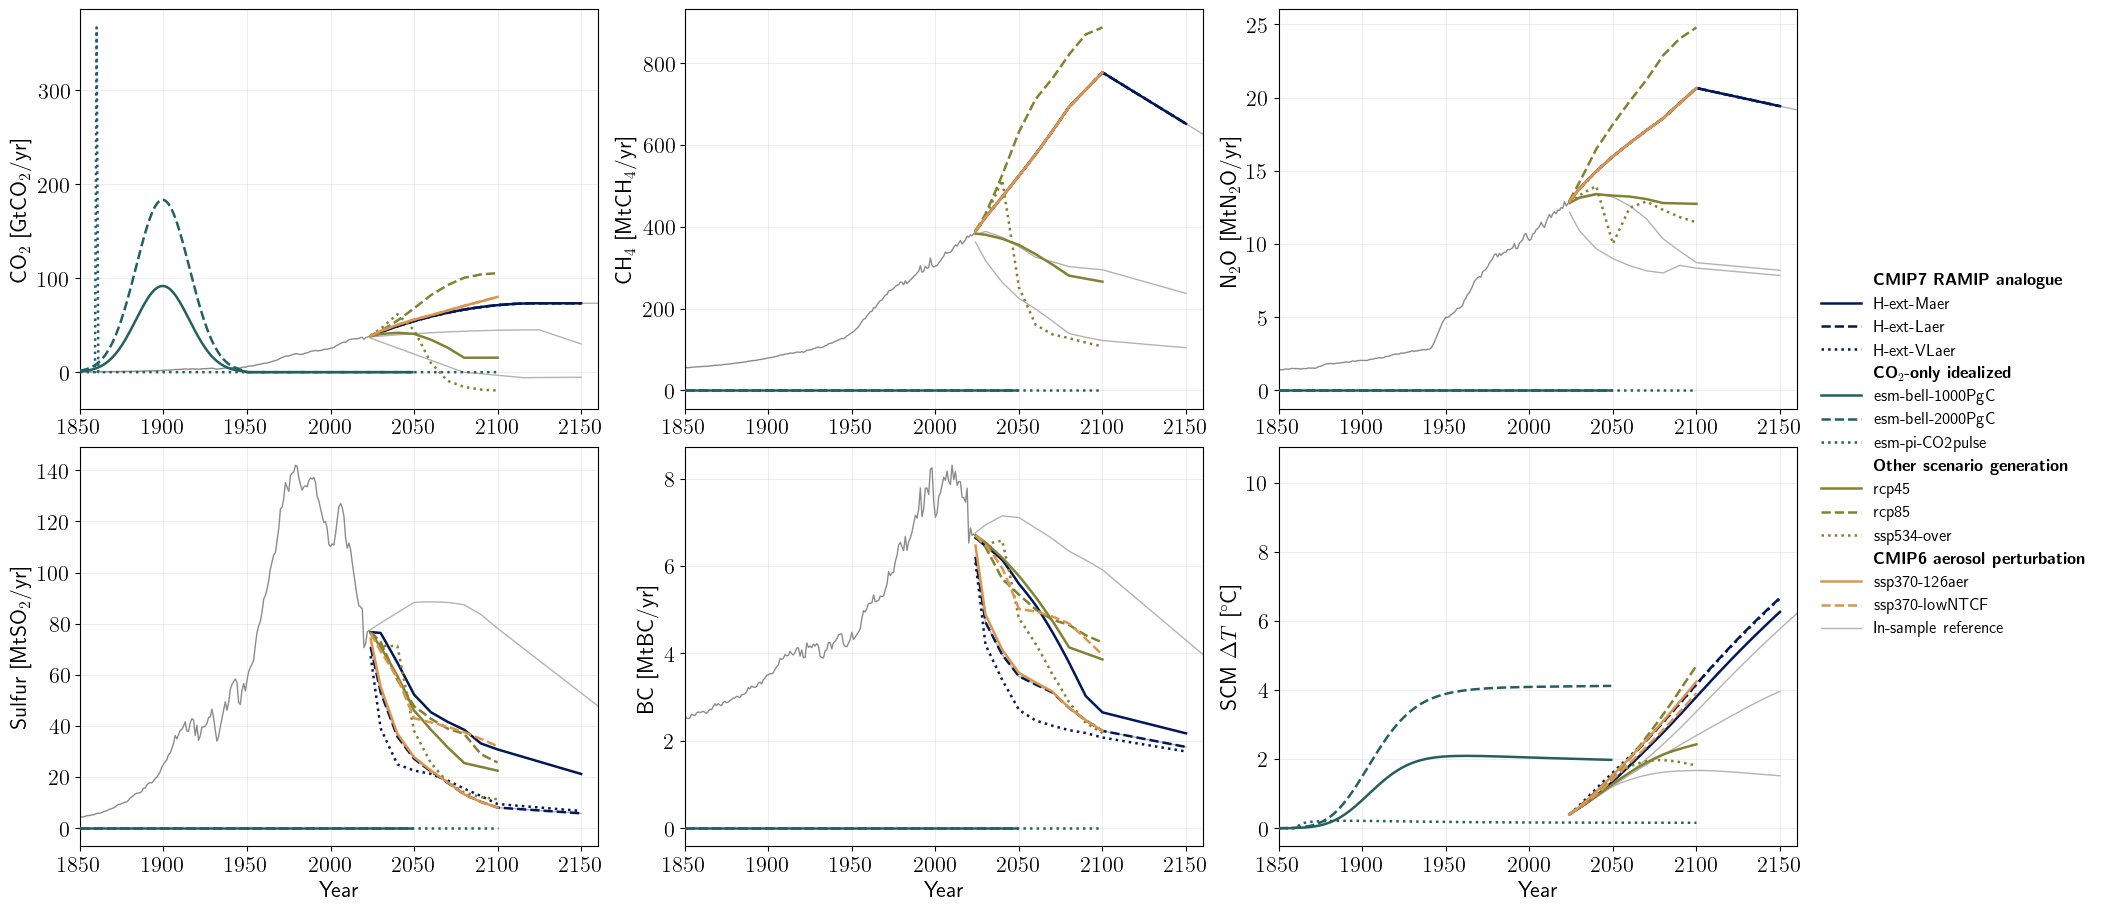

In [2]:
fig, _ = utils_plotting.plot_ood_scenario_overview(
    scenarios, save="fig6_ood_scenario_overview")

## 2. Harmonization of the RCMIP futures

Published vs. harmonized pathways, following Gidden et al. (2018),
[doi:10.1016/j.envsoft.2018.04.002](https://doi.org/10.1016/j.envsoft.2018.04.002)
— the methodology paper behind `aneris`. The vertical rules mark the harmonization
year (2023) and the convergence year (2080). The summary panel is the point of the
exercise: the handoff step before (open marker) and after (filled).

Per-species method and coefficients: `fig6_ood_harmonization.csv`.

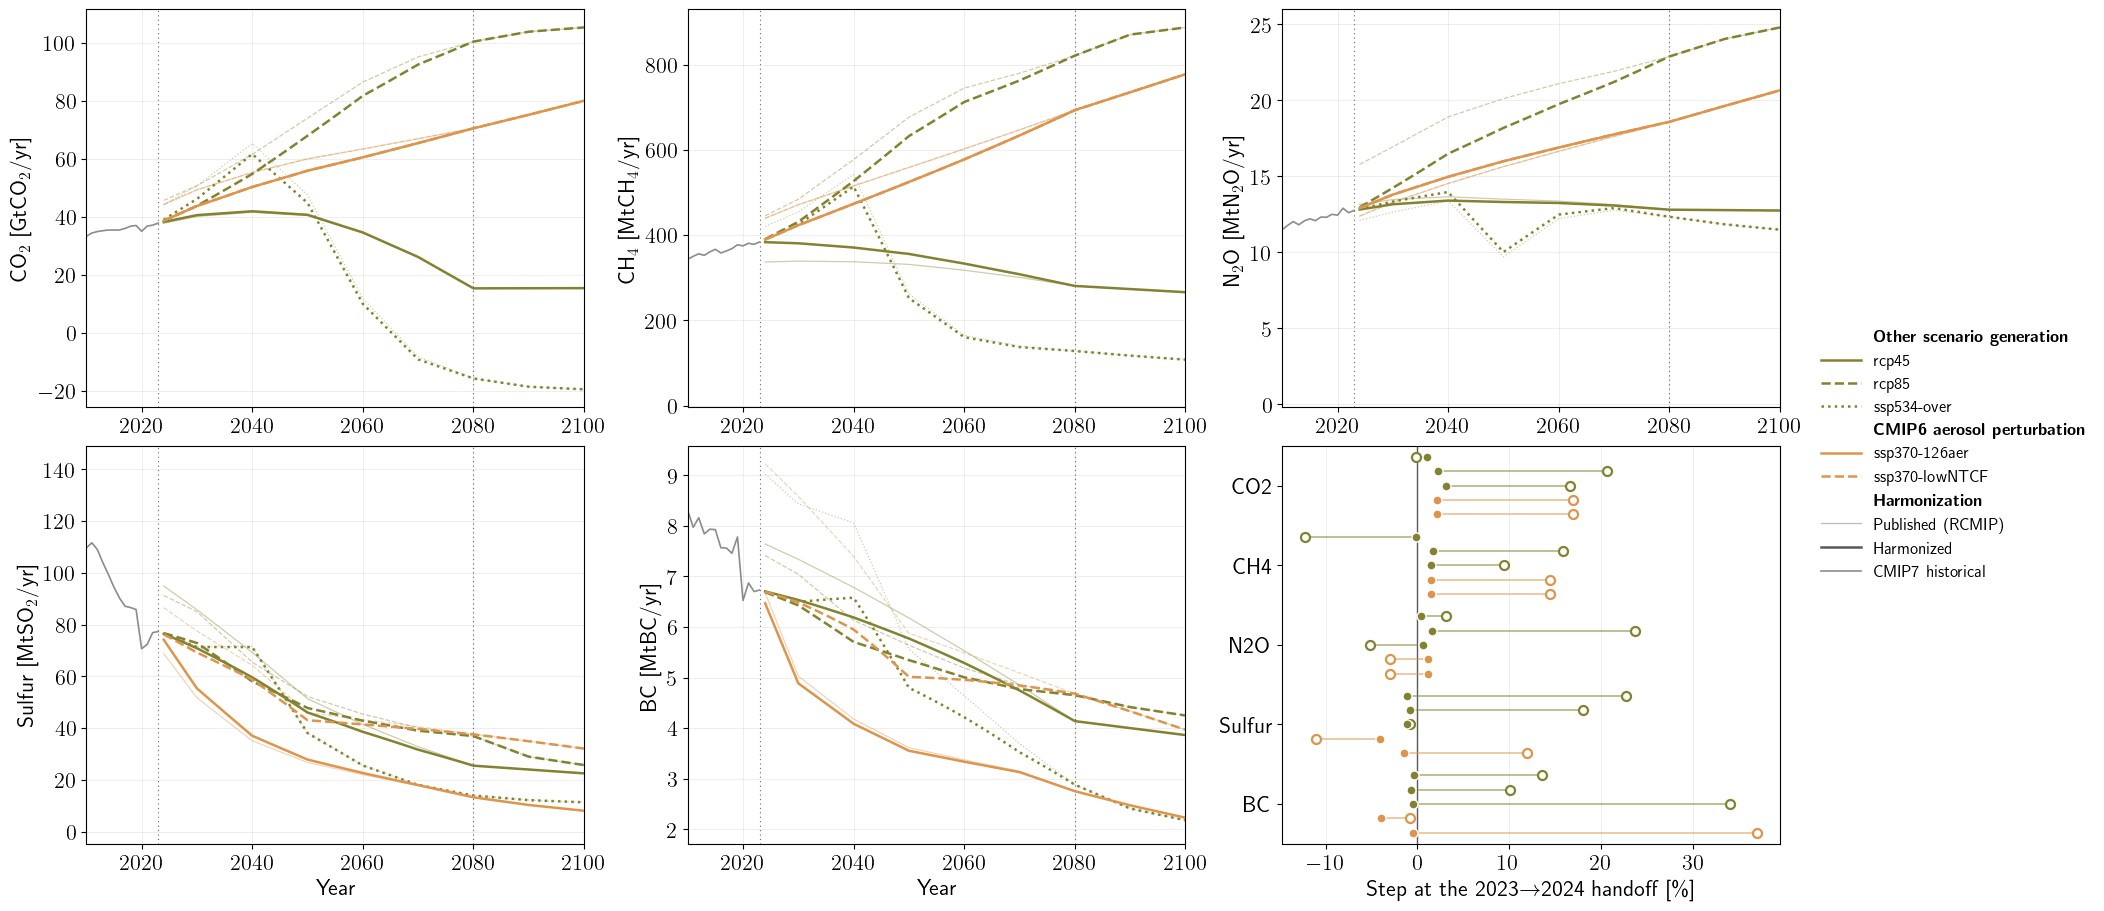

In [3]:
fig, _ = utils_plotting.plot_harmonization_diagnostic(
    scenarios, save="fig6_ood_harmonization")

## 3. Emulator performance, 50 seeds

Median with IQR across seeds, matching Figures 3/4/5/6. SCM truth black dashed,
baseline `cm.lipariS(5)`, `Opt. All` `cm.osloS(2)` — the existing Figure 6 convention.

`plot_individual_effects_summary` is deliberately untouched: its mosaic, fixed
axis limits and hardcoded legend offsets all break on a different panel count.
Survivors get folded into the real figure after downselection.

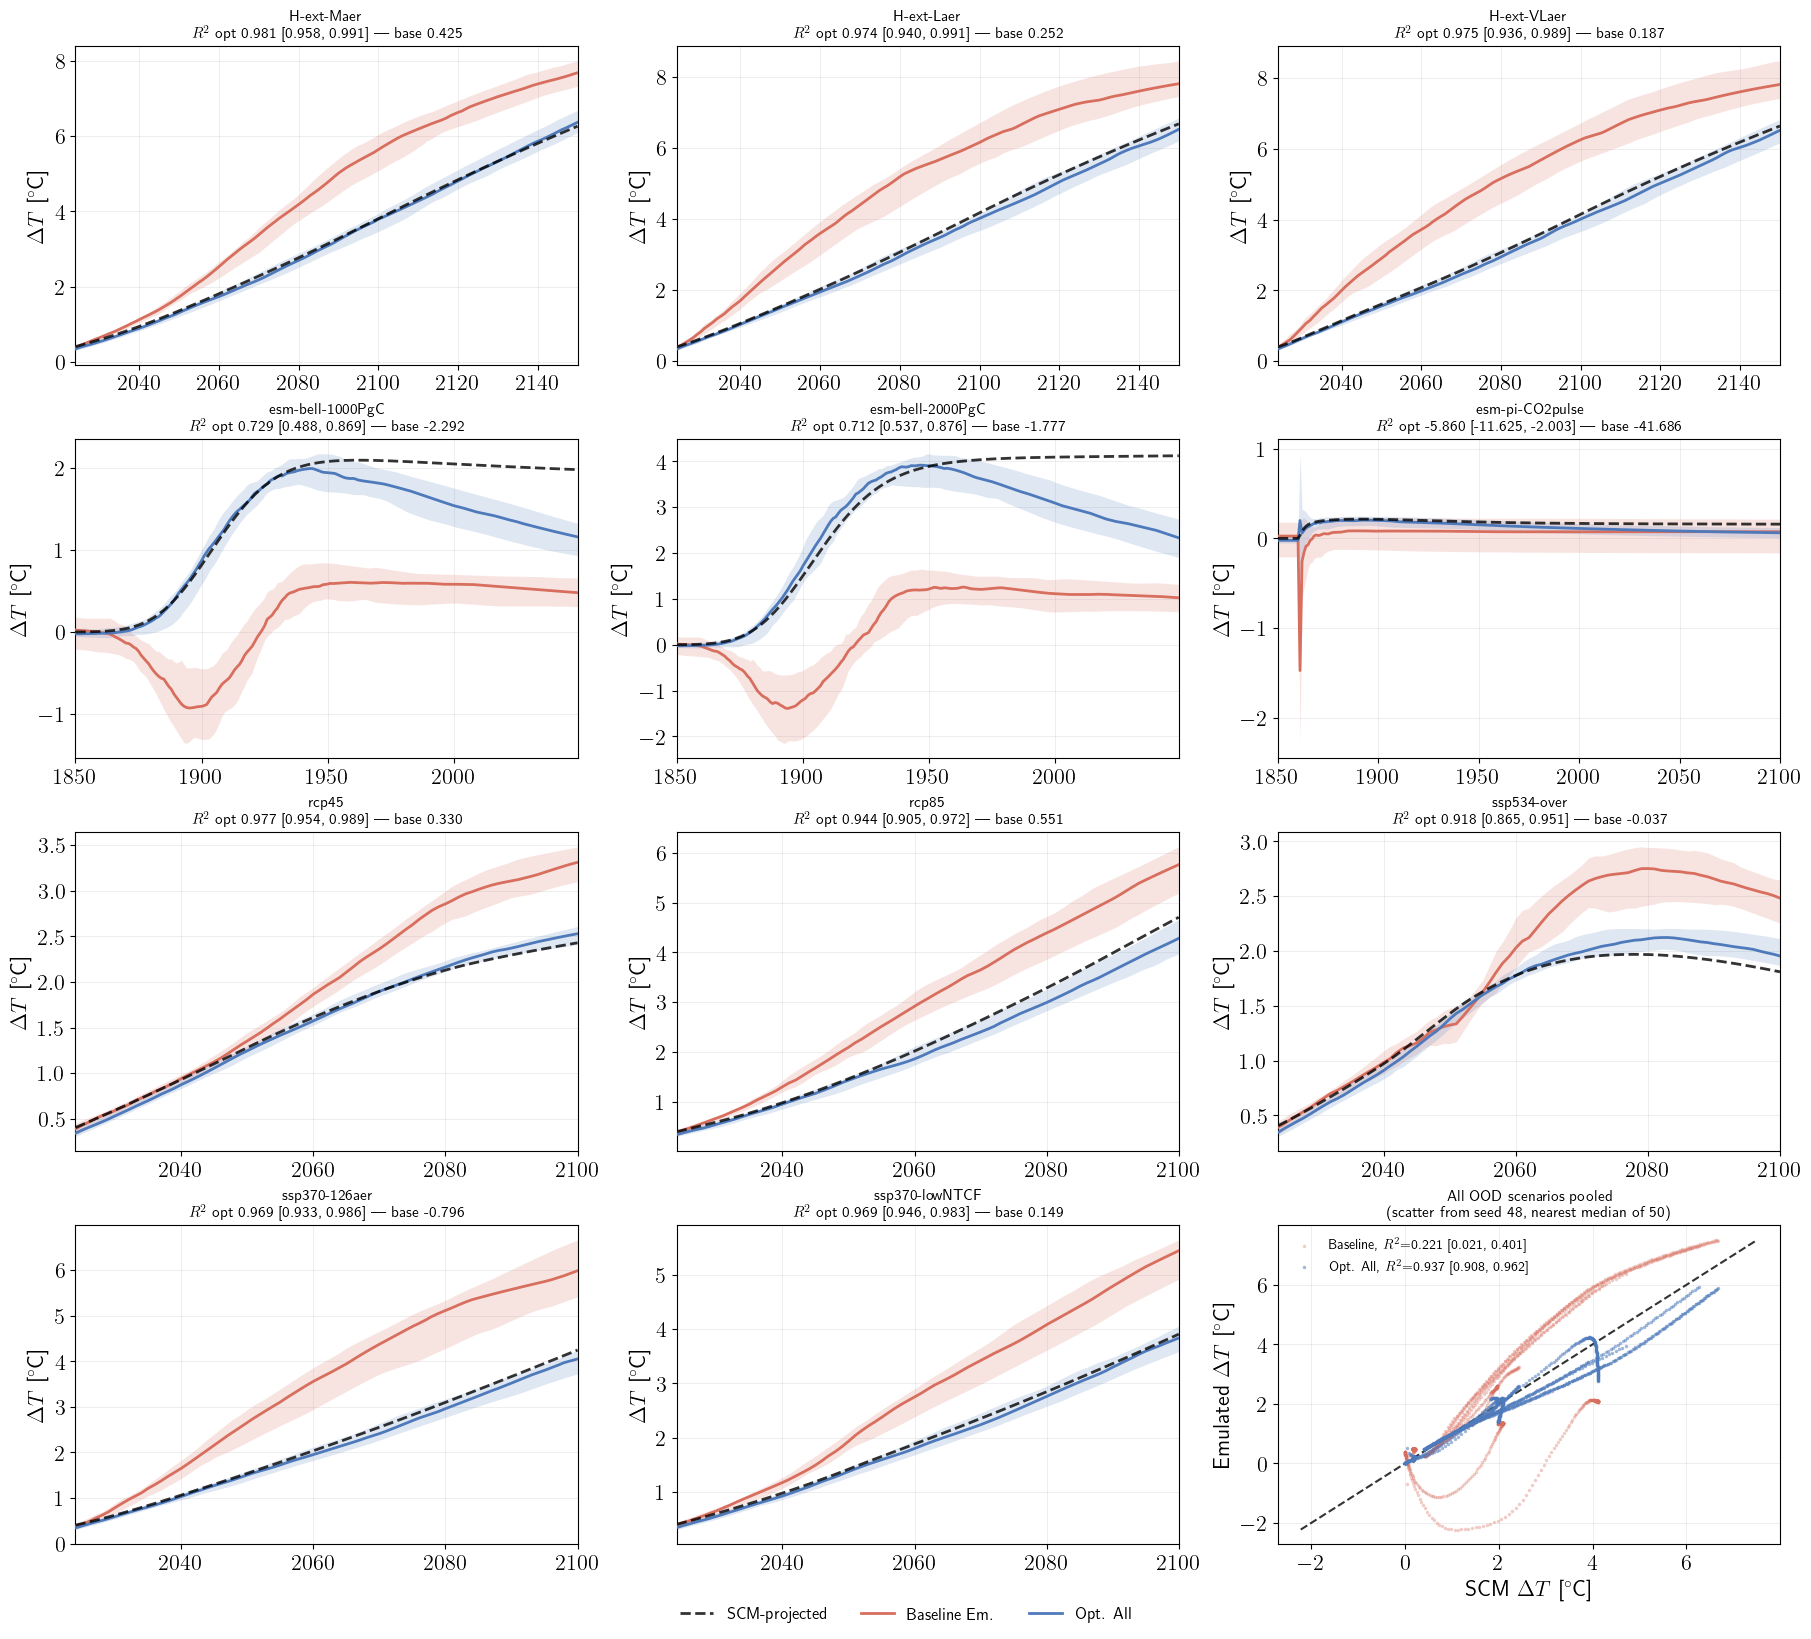

In [4]:
fig, _ = utils_plotting.plot_ood_scenario_grid(scenarios, sweep, save="fig6_ood_grid")

## 4. The supplement table

In [5]:
import csv

with open(OOD_DIR / "fig6_ood_r2_table.csv") as f:
    rows = list(csv.DictReader(f))

print(f"{'scenario':20s} {'emulator':10s} {'in-obj':7s} {'R2 median [IQR]'}")
for r in rows:
    print(f"{r['scenario']:20s} {r['emulator']:10s} {r['in_objective']:7s} "
          f"{float(r['r2_median']):+.4f} "
          f"[{float(r['r2_p25']):+.4f}, {float(r['r2_p75']):+.4f}]")

scenario             emulator   in-obj  R2 median [IQR]
H-ext-Maer           optimized  False   +0.9811 [+0.9584, +0.9914]
H-ext-Maer           baseline   False   +0.4249 [+0.2252, +0.6168]
H-ext-Laer           optimized  False   +0.9740 [+0.9396, +0.9908]
H-ext-Laer           baseline   False   +0.2520 [-0.1353, +0.6229]
H-ext-VLaer          optimized  False   +0.9752 [+0.9359, +0.9892]
H-ext-VLaer          baseline   False   +0.1867 [-0.2625, +0.5526]
esm-bell-1000PgC     optimized  False   +0.7287 [+0.4878, +0.8687]
esm-bell-1000PgC     baseline   False   -2.2919 [-2.8945, -1.4641]
esm-bell-2000PgC     optimized  False   +0.7118 [+0.5370, +0.8762]
esm-bell-2000PgC     baseline   False   -1.7773 [-2.4577, -1.3166]
esm-pi-CO2pulse      optimized  False   -5.8596 [-11.6246, -2.0032]
esm-pi-CO2pulse      baseline   False   -41.6859 [-73.1475, -14.6793]
rcp45                optimized  False   +0.9765 [+0.9539, +0.9886]
rcp45                baseline   False   +0.3302 [+0.0665, +0.6684]
rc